# Analyse a SHARC ensemble

Set `ENSEMBLE_PATH` to the ensemble root folder, set (1-based) atomic indices, then Run All

In [1]:
# Input ensemble information

from pathlib import Path

ENSEMBLE_PATH = Path("/home/lim_yt/X-MACE-tools/sharc_scripts/sharc_mace_scripts/output/ethene_01_dynamic_random")
MAXIMUM_TIME_FS = 1000.0 # trajectory information after this time will be cut off
FILTER_SETTINGS_PATH = Path("../../../data_helpers/filtering/null_filter_for_testing.json")

DIHEDRAL_INDICES = (3, 1, 2, 4)
BOND_LENGTH_INDICES = (1, 2)

BONDS = [
    (1, 2),
    (1, 3),
    (1, 4),
]


In [2]:
# Imports and parse ensemble

import sys
import matplotlib.pyplot as plt
import pandas as pd

repository_path = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "sharc_scripts" / "tools" / "parse_sharc_output.py").is_file()
)
sys.path[:0] = [str(repository_path)]

from data_helpers.filtering.filter_sharc_ensemble import filter_sharc_ensemble
from sharc_scripts.tools.ensemble_tools.calc_quantum_yield import calculate_quantum_yield
from sharc_scripts.tools.ensemble_tools.calc_state_populations import calculate_state_populations
from sharc_scripts.tools.ensemble_tools.plot_hop_geoms import plot_hop_geoms
from sharc_scripts.tools.parse_sharc_output import read_sharc_ensemble

raw_ensemble = read_sharc_ensemble(
    ENSEMBLE_PATH,
    maximum_time_fs=MAXIMUM_TIME_FS,
)


Total trajectories: 100
Filtered: 0
Unfiltered: 100
Zero retained frames (failed filter at first frame): 0


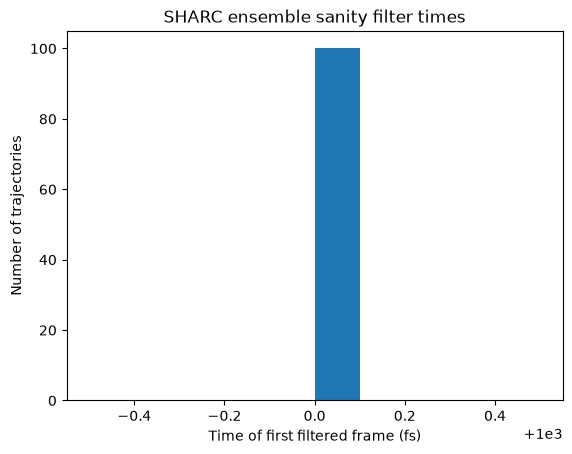

In [3]:
# Filter ensemble using SHNITSEL defaults

filter_result = filter_sharc_ensemble(
    raw_ensemble,
    FILTER_SETTINGS_PATH,
    BONDS,
)

ensemble = filter_result["ensemble"]
trajectory_results = filter_result["trajectory_results"]

n_filtered = sum(result["filtered"] for result in trajectory_results)
n_zero_retained = sum(
    not result["filtered_trajectory"].frames for result in trajectory_results
)
print(f"Total trajectories: {len(trajectory_results)}")
print(f"Filtered: {n_filtered}")
print(f"Unfiltered: {len(trajectory_results) - n_filtered}")
print(f"Zero retained frames (failed filter at first frame): {n_zero_retained}")

failure_times = [
    result["time_fs"] if result["filtered"] else MAXIMUM_TIME_FS
    for result in trajectory_results
]
plt.hist(failure_times)
plt.xlabel("Time of first filtered frame (fs)")
plt.ylabel("Number of trajectories")
plt.title("SHARC ensemble sanity filter times")
plt.show()


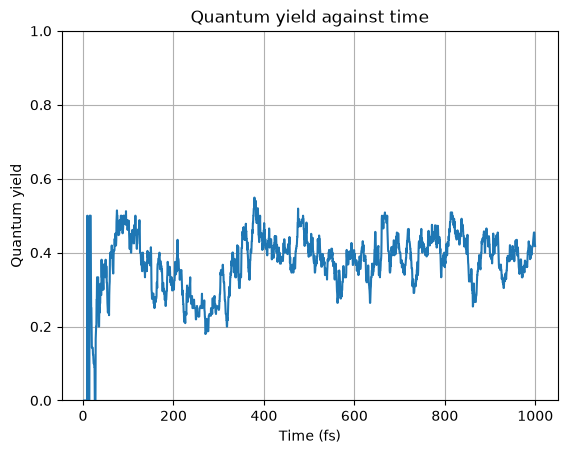

In [4]:
# Plot quantum yield against time

analysis_times = sorted({
    frame.time_fs
    for trajectory in raw_ensemble.trajectories
    for frame in trajectory.frames
    if frame.time_fs <= MAXIMUM_TIME_FS
})

quantum_yield_results = [
    calculate_quantum_yield(ensemble, DIHEDRAL_INDICES, time_fs)
    for time_fs in analysis_times
]
plt.plot(
    analysis_times,
    [result["quantum_yield"] for result in quantum_yield_results],
)
plt.xlabel("Time (fs)")
plt.ylabel("Quantum yield")
plt.ylim(0, 1)
plt.title("Quantum yield against time")
plt.grid()
plt.show()


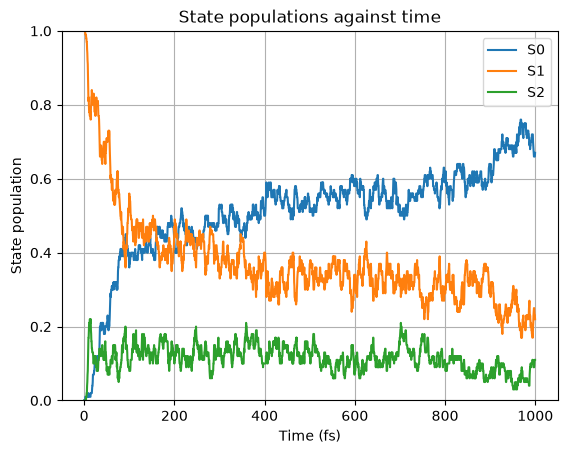

In [5]:
# Plot state populations against time

population_results = [
    calculate_state_populations(ensemble, time_fs)
    for time_fs in analysis_times
]
state_labels = sorted(
    {state for populations in population_results for state in populations},
    key=lambda state: int(state.removeprefix("S")),
)
for state in state_labels:
    values = [populations.get(state, 0.0) for populations in population_results]
    plt.plot(analysis_times, values, label=state)
plt.xlabel("Time (fs)")
plt.ylabel("State population")
plt.ylim(0, 1)
plt.title("State populations against time")
plt.legend()
plt.grid()
plt.show()


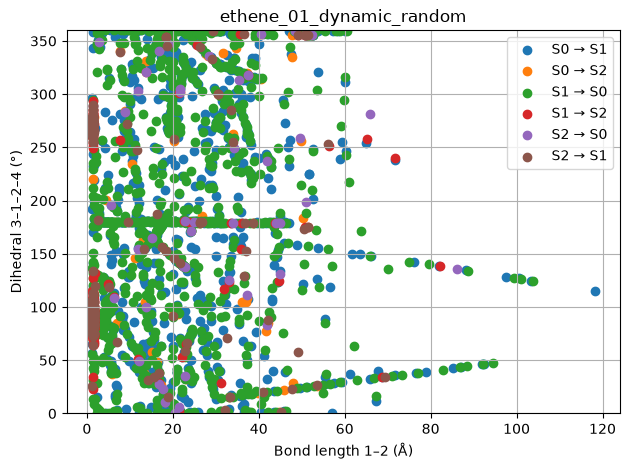

In [6]:
# Plot hop geometries

fig, ax = plot_hop_geoms(
    ensemble,
    bond_length_indices=BOND_LENGTH_INDICES,
    dihedral_indices=DIHEDRAL_INDICES,
)
ax.set_ylim(0, 360)
plt.show()
